
# Day 34 — Neural Networks, Activation Functions & Backpropagation

## Theory Heavy + Hands-on Notebook

This notebook covers:

- Neural Networks Overview
- Neurons, Weights, Biases
- Activation Functions
- Sigmoid, Tanh, ReLU, Leaky ReLU, Softplus, Softmax
- Backpropagation Intuition
- Gradient Descent
- Vanishing Gradient Problem
- Practical Visualizations
- Hands-on Neural Network Examples
- Deep Learning Intuition

---

# Learning Goal

Understand:

1. Why neural networks work
2. Why activation functions are needed
3. How backpropagation trains networks
4. Why ReLU changed deep learning
5. How gradients update weights



# 1. What is a Neural Network?

A Neural Network is a machine learning model inspired by the biological brain.

It consists of interconnected neurons that process information layer by layer.

Basic Flow:

```text
Input Layer → Hidden Layers → Output Layer
```

Example:

```text
Customer Features → Neural Network → Fraud Prediction
```

Each neuron performs:

```text
Weighted Sum + Bias → Activation Function
```

Mathematically:

```text
z = w1x1 + w2x2 + b
a = activation(z)
```

Where:

- x = inputs
- w = weights
- b = bias
- z = weighted sum
- a = activated output



# 2. Why Activation Functions Are Needed

Without activation functions:

```text
Neural Network = Linear Equation
```

Even 100 hidden layers would behave like simple linear regression.

Activation functions introduce:

✅ Non-linearity

This allows neural networks to learn:

- Images
- Speech
- Language
- Fraud patterns
- Medical diagnosis
- Recommendations



# 3. Common Activation Functions

| Activation | Range | Best Use |
|---|---|---|
| Sigmoid | 0 to 1 | Binary classification |
| Tanh | -1 to 1 | Hidden layers |
| ReLU | 0 to ∞ | Deep learning |
| Leaky ReLU | Slight negatives allowed | Deep networks |
| Softplus | Smooth ReLU | Stable optimization |
| Softmax | Probabilities | Multiclass output |


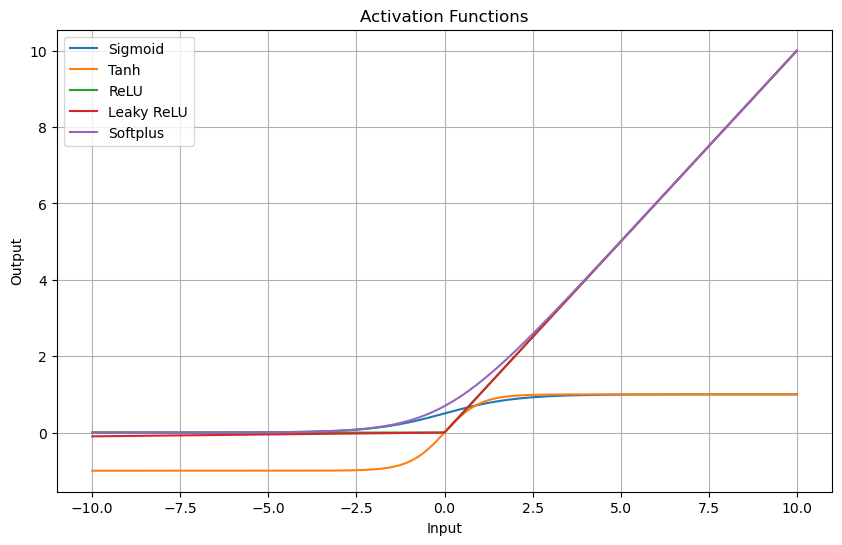

In [3]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 500)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.01 * x)
softplus = np.log(1 + np.exp(x))

plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')
plt.plot(x, leaky_relu, label='Leaky ReLU')
plt.plot(x, softplus, label='Softplus')

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()



# 4. Sigmoid Activation Function

Formula:

```text
σ(x) = 1 / (1 + e^-x)
```

Output range:

```text
0 to 1
```

Advantages:

✅ Smooth output

✅ Probability interpretation

Limitations:

❌ Vanishing gradient

❌ Slow training in deep networks


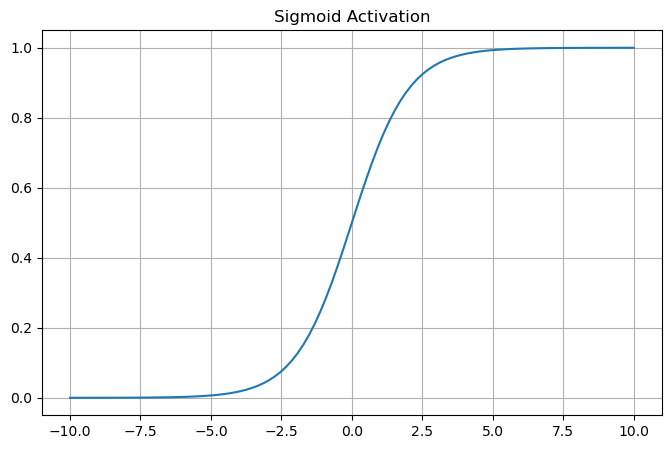

In [4]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title("Sigmoid Activation")
plt.grid(True)
plt.show()



# 5. Tanh Activation Function

Formula:

```text
tanh(x)
```

Range:

```text
-1 to 1
```

Advantages:

✅ Zero-centered outputs

✅ Better hidden layer behavior than sigmoid

Limitation:

❌ Still suffers vanishing gradients


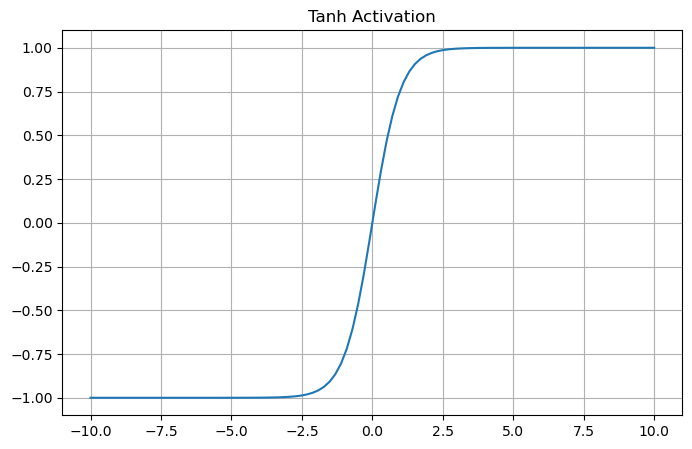

In [5]:

x = np.linspace(-10, 10, 100)
y = np.tanh(x)

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title("Tanh Activation")
plt.grid(True)
plt.show()



# 6. ReLU Activation Function

Formula:

```text
f(x) = max(0, x)
```

Behavior:

- Negative → 0
- Positive → unchanged

Why ReLU became revolutionary:

✅ Faster training

✅ Reduced vanishing gradient problem

✅ Computationally efficient

Limitation:

❌ Dying ReLU problem


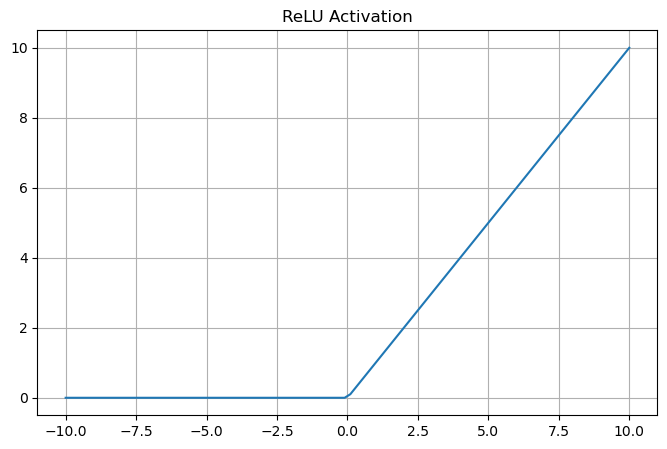

In [6]:

x = np.linspace(-10, 10, 100)
y = np.maximum(0, x)

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title("ReLU Activation")
plt.grid(True)
plt.show()



# 7. Leaky ReLU

Improved ReLU.

Formula:

```text
f(x)=x if x>0 else 0.01x
```

Advantage:

✅ Prevents dead neurons


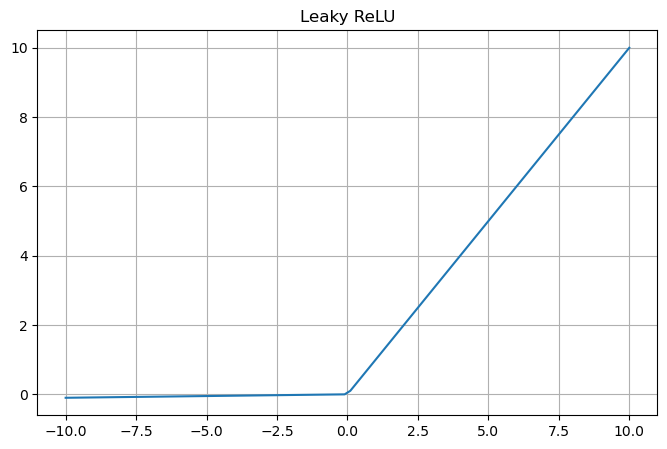

In [7]:

x = np.linspace(-10, 10, 100)
y = np.where(x > 0, x, 0.01 * x)

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title("Leaky ReLU")
plt.grid(True)
plt.show()



# 8. Softplus Activation Function

Softplus is a smooth version of ReLU.

Formula:

```text
f(x)=ln(1+e^x)
```

Advantages:

✅ Smooth gradients

✅ No sharp corner

✅ Reduces dead neuron issue

Limitations:

❌ Slower computation


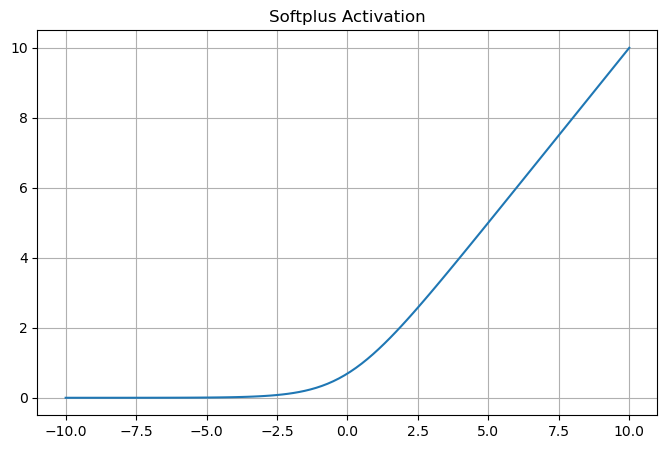

In [8]:

x = np.linspace(-10, 10, 100)
y = np.log(1 + np.exp(x))

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title("Softplus Activation")
plt.grid(True)
plt.show()



# 9. Softmax Activation Function

Used for multiclass classification.

Example:

```text
Cat → 0.7
Dog → 0.2
Bird → 0.1
```

Probabilities sum to 1.


In [9]:

def softmax(x):
    exp_values = np.exp(x - np.max(x))
    return exp_values / np.sum(exp_values)

scores = np.array([2.0, 1.0, 0.1])

probabilities = softmax(scores)

print("Softmax Probabilities:")
print(probabilities)
print("Sum:", probabilities.sum())


Softmax Probabilities:
[0.65900114 0.24243297 0.09856589]
Sum: 1.0



# 10. What is Backpropagation?

Backpropagation is the learning mechanism of neural networks.

It calculates:

```text
How wrong the prediction was
```

and updates weights to reduce future error.

Core idea:

```text
Prediction → Error → Weight Update
```

This process repeats many times.



# 11. Forward Propagation vs Backpropagation

## Forward Propagation

Input flows forward.

```text
Input → Hidden Layer → Output
```

Prediction generated.

---

## Backpropagation

Error flows backward.

```text
Output Error → Hidden Layers → Weight Updates
```



# 12. Gradient Descent Intuition

Imagine climbing down a hill blindfolded.

You check slope direction:

- steep → large step
- gentle → small step

Goal:

```text
Reach minimum error
```

Update rule:

```text
New Weight = Old Weight - Learning Rate × Gradient
```


In [10]:

# Simple Gradient Descent Example

weight = 5
learning_rate = 0.1

for step in range(10):

    gradient = 2 * weight

    weight = weight - learning_rate * gradient

    print(f"Step {step+1}: Weight = {weight:.4f}")


Step 1: Weight = 4.0000
Step 2: Weight = 3.2000
Step 3: Weight = 2.5600
Step 4: Weight = 2.0480
Step 5: Weight = 1.6384
Step 6: Weight = 1.3107
Step 7: Weight = 1.0486
Step 8: Weight = 0.8389
Step 9: Weight = 0.6711
Step 10: Weight = 0.5369



# 13. Vanishing Gradient Problem

In deep networks:

Gradients can become extremely small.

Result:

❌ Earlier layers learn very slowly

This was a major issue before ReLU.

Sigmoid and Tanh are more affected.

ReLU helped solve this problem.



# 14. Hands-on Neural Network with Scikit-learn


In [11]:

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Generate dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Neural network
model = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation='relu',
    max_iter=1000,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 0.98


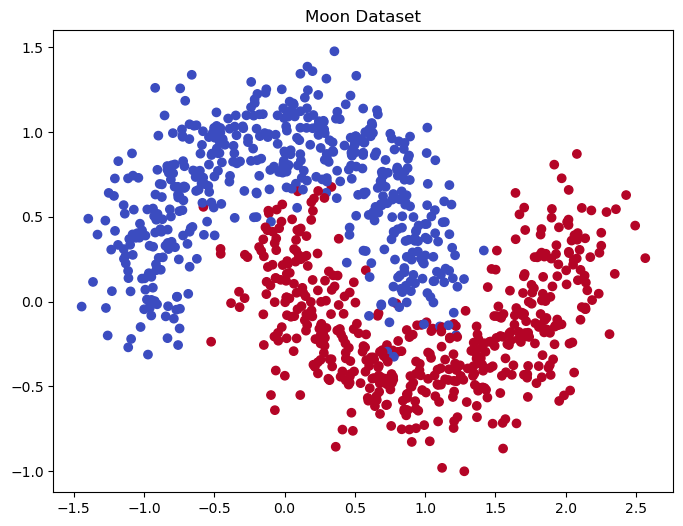

In [12]:

# Visualizing the dataset

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='coolwarm'
)

plt.title("Moon Dataset")
plt.show()



# 15. Why Neural Networks Became Dominant

Neural networks enabled breakthroughs in:

- Computer Vision
- NLP
- Speech Recognition
- LLMs
- Generative AI
- Recommendation Systems
- Fraud Detection

Modern AI systems like ChatGPT are built on deep neural networks.



# 16. BFSI Real-World Example — Fraud Detection

Input Features:

- Transaction amount
- Device ID
- Login location
- Merchant category
- Transaction timing

Neural network learns:

```text
Normal vs suspicious transaction behavior
```

Backpropagation continuously improves prediction quality.



# 17. Advantages of Neural Networks

✅ Learns complex patterns

✅ Excellent for unstructured data

✅ Automatic feature learning

✅ High accuracy

✅ Foundation of Deep Learning



# 18. Limitations of Neural Networks

❌ Requires large datasets

❌ Computationally expensive

❌ Hard to interpret

❌ Risk of overfitting

❌ Long training time



# 19. Interview Questions

## Q1. Why do we need activation functions?

To introduce non-linearity.

---

## Q2. Why is ReLU popular?

Because it trains faster and reduces vanishing gradients.

---

## Q3. What does backpropagation do?

Calculates error gradients and updates weights.

---

## Q4. What is vanishing gradient?

Gradients becoming too small in deep networks.

---

## Q5. Difference between Sigmoid and Softmax?

- Sigmoid → Binary classification
- Softmax → Multiclass classification



# 20. Final Mental Model

```text
Forward Propagation:
Prediction happens

Loss Function:
Error measured

Backpropagation:
Error distributed backward

Gradient Descent:
Weights corrected

Repeat:
Network improves
```

---

# End of Notebook
